<a href="https://colab.research.google.com/github/dee431/-_Apple_Products_Pricing_Dataset_-2023-2026-.ipynb/blob/main/%F0%9F%8D%8E_Apple_Products_Pricing_Dataset_(2023%E2%80%932026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1 — Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

import joblib

**Cell 2 — Load Dataset**

In [ ]:
df = pd.read_csv("/content/Apple_Products_Pricing_Dataset_5000_Enhanced.csv")

df.head()

,Serial Number,Product Category,Product Name,Platform,Launch Price,Current Price,Discount Percentage,Ratings,Reviews Count,Stock Status,Sale Event,Condition,Date,Color,RAM,Storage
0,1,AirPods,AirPods 2,Amazon,83941,75100,10.53,4.1,7998,Low Stock,Great Indian Festival,Refurbished,2024-07-21,Titanium,24GB,256GB
1,2,AirPods,AirPods 2,Flipkart,272125,230323,15.36,4.7,27743,Out of Stock,Diwali Sale,New,2025-07-31,Gold,6GB,1TB
2,3,AirPods,AirPods 2,Flipkart,27297,22830,16.36,4.7,38302,Low Stock,Republic Day Sale,Refurbished,2024-11-12,Space Gray,24GB,1TB
3,4,AirPods,AirPods 2,Croma,141289,126103,10.75,4.2,15743,Out of Stock,Great Indian Festival,New,2024-07-17,White,36GB,128GB
4,5,AirPods,AirPods 2,Croma,292253,213216,27.04,4.5,40298,Pre-order,Diwali Sale,Refurbished,2025-04-23,Blue,6GB,1TB


**Cell 3 - New Interactive Sheet**

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1LjAYLuzdfw0Rgg14Wyfxdy1847aet7IBF7UueP2E6dc/edit#gid=0


**Cell 4 — Dataset Information**

In [ ]:
print(df.shape)

df.info()

df.describe()

df.head()

(5000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Serial Number        5000 non-null   int64  
 1   Product Category     5000 non-null   object 
 2   Product Name         5000 non-null   object 
 3   Platform             5000 non-null   object 
 4   Launch Price         5000 non-null   int64  
 5   Current Price        5000 non-null   int64  
 6   Discount Percentage  5000 non-null   float64
 7   Ratings              5000 non-null   float64
 8   Reviews Count        5000 non-null   int64  
 9   Stock Status         5000 non-null   object 
 10  Sale Event           5000 non-null   object 
 11  Condition            5000 non-null   object 
 12  Date                 5000 non-null   object 
 13  Color                5000 non-null   object 
 14  RAM                  5000 non-null   object 
 15  Storage              5000 n

,Serial Number,Product Category,Product Name,Platform,Launch Price,Current Price,Discount Percentage,Ratings,Reviews Count,Stock Status,Sale Event,Condition,Date,Color,RAM,Storage
0,1,AirPods,AirPods 2,Amazon,83941,75100,10.53,4.1,7998,Low Stock,Great Indian Festival,Refurbished,2024-07-21,Titanium,24GB,256GB
1,2,AirPods,AirPods 2,Flipkart,272125,230323,15.36,4.7,27743,Out of Stock,Diwali Sale,New,2025-07-31,Gold,6GB,1TB
2,3,AirPods,AirPods 2,Flipkart,27297,22830,16.36,4.7,38302,Low Stock,Republic Day Sale,Refurbished,2024-11-12,Space Gray,24GB,1TB
3,4,AirPods,AirPods 2,Croma,141289,126103,10.75,4.2,15743,Out of Stock,Great Indian Festival,New,2024-07-17,White,36GB,128GB
4,5,AirPods,AirPods 2,Croma,292253,213216,27.04,4.5,40298,Pre-order,Diwali Sale,Refurbished,2025-04-23,Blue,6GB,1TB


**Cell 4 — Missing Values**

In [ ]:
print(df.isnull().sum())

df = df.dropna()

print(df.isnull().sum())

Serial Number          0
Product Category       0
Product Name           0
Platform               0
Launch Price           0
Current Price          0
Discount Percentage    0
Ratings                0
Reviews Count          0
Stock Status           0
Sale Event             0
Condition              0
Date                   0
Color                  0
RAM                    0
Storage                0
dtype: int64
Serial Number          0
Product Category       0
Product Name           0
Platform               0
Launch Price           0
Current Price          0
Discount Percentage    0
Ratings                0
Reviews Count          0
Stock Status           0
Sale Event             0
Condition              0
Date                   0
Color                  0
RAM                    0
Storage                0
dtype: int64


**Cell 5 — Keep Required Columns**

In [ ]:
df = df[['Product Name','Storage','Current Price']].copy()

**Cell 6 — Encode Product Name**

In [ ]:
product_encoder = LabelEncoder()

df['Product Name'] = product_encoder.fit_transform(df['Product Name'])

**Cell 7 — Encode Storage**

In [ ]:
storage_map = {
    '64GB':64,
    '128GB':128,
    '256GB':256,
    '512GB':512,
    '1TB':1024
}

df['Storage'] = df['Storage'].map(storage_map)

**Cell 8 — Prepare Data**

In [ ]:
X = df[['Product Name','Storage']]

y = df['Current Price']

**Cell 9 — Train Test Split**

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

**Cell 10 — Train Model**

In [ ]:
model = RandomForestRegressor(

    n_estimators=300,
    random_state=42

)

model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

**Cell 11 — Evaluate Model**

In [ ]:
prediction = model.predict(X_test)

mae = mean_absolute_error(y_test,prediction)

rmse = np.sqrt(mean_squared_error(y_test,prediction))

r2 = r2_score(y_test,prediction)

print("MAE :",mae)

print("RMSE :",rmse)

print("R2 Score :",r2)

MAE : 73910.50338525769
RMSE : 86637.27995502646
R2 Score : -0.03272308320757289


**Cell 12 — Save Model**

In [ ]:
joblib.dump(model,"apple_price_model.pkl")

joblib.dump(product_encoder,"product_encoder.pkl")

['product_encoder.pkl']

**Cell 13 — Load Model**

In [ ]:
model = joblib.load("apple_price_model.pkl")

encoder = joblib.load("product_encoder.pkl")

**Cell 14 — Prediction Function**

In [ ]:
def predict_price(product, storage):
    # Try to find an exact match first
    if product not in encoder.classes_:
        # If no exact match, try to find a product that starts with or contains the input string
        matches = [c for c in encoder.classes_ if product.lower() in c.lower()]
        if matches:
            # Use the first match found (e.g., 'iPhone 16' -> 'iPhone 16 128GB')
            product = matches[0]
        else:
            print(f"Error: Product '{product}' is not recognized.")
            return None

    product_encoded = encoder.transform([product])[0]

    storage_map = {
        '64GB': 64,
        '128GB': 128,
        '256GB': 256,
        '512GB': 512,
        '1TB': 1024
    }

    # Ensure storage string is in the map
    if storage not in storage_map:
        print(f"Error: Storage '{storage}' is not valid.")
        return None

    storage_val = storage_map[storage]

    # Predict
    price = model.predict([[product_encoded, storage_val]])

    return price[0]

**Cell 15 — User Input**

In [ ]:
# @title Product Price Predictor
# Load the encoder to populate the dropdown
import joblib
try:
    encoder = joblib.load("product_encoder.pkl")
    product_list = sorted(list(encoder.classes_))
except:
    product_list = ["Run previous cells first"]

# @markdown Select a product and storage to predict its price:
product = "Mac Pro 1TB" # @param ["AirPods 2", "AirPods 3", "AirPods 4", "AirPods Max", "AirPods Pro 2", "Apple TV 4K Ethernet", "Apple TV 4K WiFi", "Apple TV HD", "Apple Watch SE", "Apple Watch Series 10", "Apple Watch Series 9", "Apple Watch Ultra", "Apple Watch Ultra 2", "HomePod Gen2", "HomePod mini", "Mac Pro 1TB", "Mac Pro 256GB", "Mac Pro 512GB", "Mac Studio 1TB", "Mac Studio 256GB", "Mac Studio 512GB", "Mac mini M2 1TB", "Mac mini M2 256GB", "Mac mini M2 512GB", "MacBook Air M2 1TB", "MacBook Air M2 256GB", "MacBook Air M2 512GB", "MacBook Air M3 1TB", "MacBook Air M3 256GB", "MacBook Air M3 512GB", "MacBook Pro 14 1TB", "MacBook Pro 14 256GB", "MacBook Pro 14 512GB", "MacBook Pro 16 1TB", "MacBook Pro 16 256GB", "MacBook Pro 16 512GB", "Vision Pro 1TB", "Vision Pro 256GB", "Vision Pro 512GB", "iMac M3 1TB", "iMac M3 256GB", "iMac M3 512GB", "iPad 10th Gen 128GB", "iPad 10th Gen 1TB", "iPad 10th Gen 256GB", "iPad 10th Gen 512GB", "iPad Air M2 128GB", "iPad Air M2 1TB", "iPad Air M2 256GB", "iPad Air M2 512GB", "iPad Pro 11 128GB", "iPad Pro 11 1TB", "iPad Pro 11 256GB", "iPad Pro 11 512GB", "iPad Pro 13 128GB", "iPad Pro 13 1TB", "iPad Pro 13 256GB", "iPad Pro 13 512GB", "iPad mini 128GB", "iPad mini 1TB", "iPad mini 256GB", "iPad mini 512GB", "iPhone 14 128GB", "iPhone 14 1TB", "iPhone 14 256GB", "iPhone 14 512GB", "iPhone 15 128GB", "iPhone 15 1TB", "iPhone 15 256GB", "iPhone 15 512GB", "iPhone 15 Pro 128GB", "iPhone 15 Pro 1TB", "iPhone 15 Pro 256GB", "iPhone 15 Pro 512GB", "iPhone 15 Pro Max 128GB", "iPhone 15 Pro Max 1TB", "iPhone 15 Pro Max 256GB", "iPhone 15 Pro Max 512GB", "iPhone 16 128GB", "iPhone 16 1TB", "iPhone 16 256GB", "iPhone 16 512GB", "iPhone 16 Plus 128GB", "iPhone 16 Plus 1TB", "iPhone 16 Plus 256GB", "iPhone 16 Plus 512GB", "iPhone 16 Pro 128GB", "iPhone 16 Pro 1TB", "iPhone 16 Pro 256GB", "iPhone 16 Pro 512GB", "iPhone 16 Pro Max 128GB", "iPhone 16 Pro Max 1TB", "iPhone 16 Pro Max 256GB", "iPhone 16 Pro Max 512GB", "iPhone 16e 128GB", "iPhone 16e 1TB", "iPhone 16e 256GB", "iPhone 16e 512GB"]
storage = "1TB" # @param ["64GB", "128GB", "256GB", "512GB", "1TB"]

print(f"Selected: {product} with {storage} storage.")

**Cell 16 — Predict Price**

In [ ]:
predicted_price = predict_price(product, storage)

if predicted_price is not None:
    print(f"Predicted Price for {product}: ₹{round(predicted_price, 2):,}")
else:
    print("Could not calculate price due to invalid input.")

**Cell 17 — Actual vs Predicted Graph**

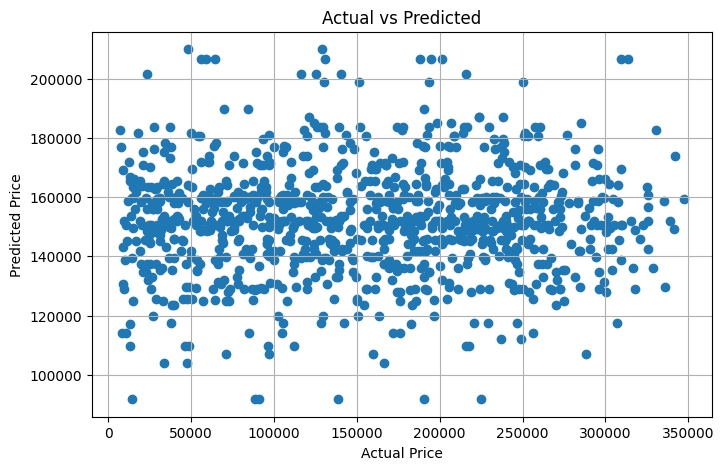

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

# --- Code added to define y_test and prediction ---
# Reload and preprocess data to get X_test, y_test
df = pd.read_csv("/content/Apple_Products_Pricing_Dataset_5000_Enhanced.csv")
df = df.dropna()
df = df[['Product Name','Storage','Current Price']].copy()

product_encoder = LabelEncoder()
df['Product Name'] = product_encoder.fit_transform(df['Product Name'])

storage_map = {
    '64GB':64,
    '128GB':128,
    '256GB':256,
    '512GB':512,
    '1TB':1024
}
df['Storage'] = df['Storage'].map(storage_map)

X = df[['Product Name','Storage']]
y = df['Current Price']

X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Load the trained model
model = joblib.load("apple_price_model.pkl")

# Make predictions
prediction = model.predict(X_test)
# --- End of added code ---

plt.figure(figsize=(8,5))

plt.scatter(y_test,prediction)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

**Cell 19 — Test on Multiple Products**

In [ ]:
print(predict_price("iPhone 16", "128GB"))

print(predict_price("iPhone 16 Pro", "512GB"))

print(predict_price("MacBook Air M3","512GB"))

print(predict_price("iPad Air M2","256GB"))

145348.46731856707
153744.70595037268
150410.71925385259
135454.6450278751


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


**Cell 20 — Project Completed**

In [ ]:
print("Apple Product Price Prediction Model Completed Successfully.")

Apple Product Price Prediction Model Completed Successfully.
